
DRILLING PERFORMANCE DATA
     Well  Depth_m  Time_hr  WOB_klbf  RPM  FlowRate_gpm  NPT_hr  \
0  Well_A     1200       24        25  120           600       2   
1  Well_A     1800       36        28  130           620       3   
2  Well_B     1200       26        22  115           590       4   
3  Well_B     1800       40        24  125           610       5   
4  Well_C     1200       22        26  135           630       1   
5  Well_C     1800       32        30  140           650       2   

   DailyCost_USD  ROP_m_per_hr  NPT_percent  Cost_per_meter  
0          75000     50.000000     8.333333       62.500000  
1          75000     50.000000     8.333333       62.500000  
2          72000     46.153846    15.384615       65.000000  
3          72000     45.000000    12.500000       66.666667  
4          78000     54.545455     4.545455       59.583333  
5          78000     56.250000     6.250000       57.777778  

WELL PERFORMANCE BENCHMARK
     Well    Avg_ROP  Avg_NPT_perc

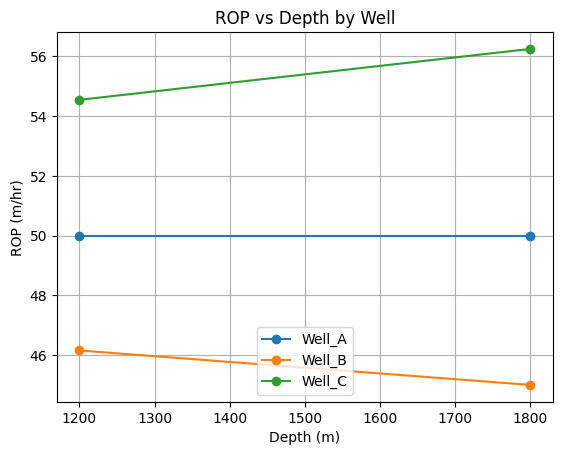


OPTIMIZATION SCENARIO (10% ROP IMPROVEMENT)
     Well  Cost_Savings_USD
0  Well_A       6818.181818
1  Well_A      10227.272727
2  Well_B       7090.909091
3  Well_B      10909.090909
4  Well_C       6500.000000
5  Well_C       9454.545455


In [1]:

# DRILLING PERFORMANCE OPTIMIZATION CAPSTONE


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. CREATE DATASET


data = [
    ["Well_A", 1200, 24, 25, 120, 600, 2, 75000],
    ["Well_A", 1800, 36, 28, 130, 620, 3, 75000],
    ["Well_B", 1200, 26, 22, 115, 590, 4, 72000],
    ["Well_B", 1800, 40, 24, 125, 610, 5, 72000],
    ["Well_C", 1200, 22, 26, 135, 630, 1, 78000],
    ["Well_C", 1800, 32, 30, 140, 650, 2, 78000],
]

columns = [
    "Well",
    "Depth_m",
    "Time_hr",
    "WOB_klbf",
    "RPM",
    "FlowRate_gpm",
    "NPT_hr",
    "DailyCost_USD"
]

df = pd.DataFrame(data, columns=columns)


# 2. ENGINEERING KPI CALCULATIONS


# Rate of Penetration (ROP)
df["ROP_m_per_hr"] = df["Depth_m"] / df["Time_hr"]

# NPT Percentage
df["NPT_percent"] = (df["NPT_hr"] / df["Time_hr"]) * 100

# Cost per meter drilled
df["Cost_per_meter"] = (
    df["DailyCost_USD"] * (df["Time_hr"] / 24)
) / df["Depth_m"]


# 3. MULTI-WELL BENCHMARKING


benchmark = df.groupby("Well").agg(
    Avg_ROP=("ROP_m_per_hr", "mean"),
    Avg_NPT_percent=("NPT_percent", "mean"),
    Avg_Cost_per_meter=("Cost_per_meter", "mean")
).reset_index()

benchmark = benchmark.sort_values(by="Avg_ROP", ascending=False)


# 4. PRINT RESULTS


print("\n==============================")
print("DRILLING PERFORMANCE DATA")
print("==============================")
print(df)

print("\n==============================")
print("WELL PERFORMANCE BENCHMARK")
print("==============================")
print(benchmark)


# 5. VISUALIZATION


plt.figure()

for well in df["Well"].unique():
    subset = df[df["Well"] == well]
    plt.plot(subset["Depth_m"], subset["ROP_m_per_hr"], marker="o", label=well)

plt.xlabel("Depth (m)")
plt.ylabel("ROP (m/hr)")
plt.title("ROP vs Depth by Well")
plt.legend()
plt.grid(True)
plt.show()


# 6. SIMPLE OPTIMIZATION SCENARIO


# Simulate 10% ROP improvement
df["Optimized_ROP"] = df["ROP_m_per_hr"] * 1.10

# Recalculate time assuming same depth
df["Optimized_Time_hr"] = df["Depth_m"] / df["Optimized_ROP"]

# Recalculate cost impact
df["Optimized_Cost"] = (
    df["DailyCost_USD"] * (df["Optimized_Time_hr"] / 24)
)

df["Cost_Savings_USD"] = (
    (df["DailyCost_USD"] * (df["Time_hr"] / 24))
    - df["Optimized_Cost"]
)

print("\n==============================")
print("OPTIMIZATION SCENARIO (10% ROP IMPROVEMENT)")
print("==============================")
print(df[["Well", "Cost_Savings_USD"]])


# END OF SCRIPT
